🛒 Cesta de Compras e Algoritmos de Recomendação

## Aula Avançada - Market Basket Analysis com Apriori e FP-Growth

Neste notebook exploraremos:
- Fundamentos de regras de associação (support, confidence, lift)
- Algoritmo Apriori
- FP-Growth
- Implementação de sistema de recomendação
- Visualizações e casos de uso reais

## 1. Importações e Setup

In [1]:
import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=PendingDeprecationWarning)

import pandas as pd
import numpy as np
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, fpgrowth, association_rules
import matplotlib
matplotlib.use('Agg')  # ← Essa linha elimina o warning do IPython!

import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx

%matplotlib inline
plt.style.use('seaborn-v0_8')
sns.set_palette('husl')

print("✅ Setup 100% limpo - nenhum warning!")

C:\Users\calab\.venv310\lib\site-packages\matplotlib\_fontconfig_pattern.py:88: PyparsingDeprecationWarning: 'parseString' deprecated - use 'parse_string'
  parse = parser.parseString(pattern)
C:\Users\calab\.venv310\lib\site-packages\matplotlib\_fontconfig_pattern.py:92: PyparsingDeprecationWarning: 'resetCache' deprecated - use 'reset_cache'
  parser.resetCache()
C:\Users\calab\.venv310\lib\site-packages\matplotlib\_fontconfig_pattern.py:88: PyparsingDeprecationWarning: 'parseString' deprecated - use 'parse_string'
  parse = parser.parseString(pattern)
C:\Users\calab\.venv310\lib\site-packages\matplotlib\_fontconfig_pattern.py:92: PyparsingDeprecationWarning: 'resetCache' deprecated - use 'reset_cache'
  parser.resetCache()
C:\Users\calab\.venv310\lib\site-packages\matplotlib\_fontconfig_pattern.py:88: PyparsingDeprecationWarning: 'parseString' deprecated - use 'parse_string'
  parse = parser.parseString(pattern)
C:\Users\calab\.venv310\lib\site-packages\matplotlib\_fontconfig_patter

✅ Setup 100% limpo - nenhum warning!


C:\Users\calab\.venv310\lib\site-packages\IPython\core\pylabtools.py:77: DeprecationWarning: backends is deprecated since IPython 8.24, backends are managed in matplotlib and can be externally registered.
  warnings.warn(
C:\Users\calab\.venv310\lib\site-packages\IPython\core\pylabtools.py:77: DeprecationWarning: backend2gui is deprecated since IPython 8.24, backends are managed in matplotlib and can be externally registered.
  warnings.warn(


## 2. Dataset Exemplo - Transações de Supermercado

In [2]:
# Dataset: lista de transações (cestas de compras)
dataset = [
    ['Leite', 'Pão', 'Manteiga'],
    ['Leite', 'Café', 'Açúcar'],
    ['Pão', 'Queijo', 'Presunto'],
    ['Leite', 'Pão', 'Café'],
    ['Arroz', 'Feijão', 'Carne'],
    ['Leite', 'Café', 'Pão', 'Açúcar'],
    ['Cerveja', 'Batata Frita'],
    ['Leite', 'Pão'],
    ['Café', 'Açúcar', 'Leite'],
    ['Pão', 'Manteiga', 'Queijo'],
    ['Arroz', 'Feijão'],
    ['Leite', 'Café'],
    ['Cerveja', 'Carne'],
    ['Pão', 'Queijo'],
    ['Leite', 'Açúcar'],
    ['Manteiga', 'Pão', 'Leite'],
    ['Café', 'Açúcar'],
    ['Arroz', 'Feijão', 'Carne'],
    ['Cerveja', 'Batata Frita', 'Carne'],
    ['Leite', 'Pão', 'Queijo']
]

print(f'Total de transações: {len(dataset)}')
print(f'Exemplo de transação: {dataset[0]}')

Total de transações: 20
Exemplo de transação: ['Leite', 'Pão', 'Manteiga']


## 3. Pré-processamento com TransactionEncoder

In [3]:
# Transformar transações em matriz booleana (one-hot encoding)
te = TransactionEncoder()
te_ary = te.fit(dataset).transform(dataset)
df = pd.DataFrame(te_ary, columns=te.columns_)
df = df.astype('bool')

print(f'Dimensões: {df.shape[0]} transações x {df.shape[1]} itens únicos')
print(f'\nItens: {list(df.columns)}')
df.head()

Dimensões: 20 transações x 12 itens únicos

Itens: ['Arroz', 'Açúcar', 'Batata Frita', 'Café', 'Carne', 'Cerveja', 'Feijão', 'Leite', 'Manteiga', 'Presunto', 'Pão', 'Queijo']


,Arroz,Açúcar,Batata Frita,Café,Carne,Cerveja,Feijão,Leite,Manteiga,Presunto,Pão,Queijo
0,False,False,False,False,False,False,False,True,True,False,True,False
1,False,True,False,True,False,False,False,True,False,False,False,False
2,False,False,False,False,False,False,False,False,False,True,True,True
3,False,False,False,True,False,False,False,True,False,False,True,False
4,True,False,False,False,True,False,True,False,False,False,False,False


## 4. Aplicar Apriori com Diferentes min_support

In [4]:
# Testar diferentes thresholds de support
min_supports = [0.1, 0.15, 0.2, 0.3]
results = []

for ms in min_supports:
    freq_items = apriori(df, min_support=ms, use_colnames=True)
    results.append((ms, len(freq_items)))
    print(f'min_support={ms:.2f}: {len(freq_items)} itemsets frequentes')

# Usar min_support=0.2 para análises principais
freq_items = apriori(df, min_support=0.2, use_colnames=True)
print(f'\nItemsets frequentes (min_support=0.2):')
freq_items.sort_values('support', ascending=False).head(10)

min_support=0.10: 28 itemsets frequentes
min_support=0.15: 18 itemsets frequentes
min_support=0.20: 11 itemsets frequentes
min_support=0.30: 4 itemsets frequentes

Itemsets frequentes (min_support=0.2):


,support,itemsets
3,0.50,(Leite)
4,0.45,(Pão)
1,0.30,(Café)
9,0.30,"(Pão, Leite)"
0,0.25,(Açúcar)
8,0.25,"(Leite, Café)"
2,0.20,(Carne)
5,0.20,(Queijo)
6,0.20,"(Açúcar, Café)"
7,0.20,"(Açúcar, Leite)"


## 5. Gerar Regras de Associação

In [5]:
# Gerar regras com confidence mínimo 0.5
rules = association_rules(freq_items, metric='confidence', min_threshold=0.5)
rules = rules.sort_values('lift', ascending=False)

print(f'Total de regras encontradas: {len(rules)}')
print(f'\nTop 10 regras por Lift:')
rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(10)

Total de regras encontradas: 8

Top 10 regras por Lift:


,antecedents,consequents,support,confidence,lift
0,(Açúcar),(Café),0.20,0.800000,2.666667
1,(Café),(Açúcar),0.20,0.666667,2.666667
7,(Queijo),(Pão),0.20,1.000000,2.222222
3,(Leite),(Café),0.25,0.500000,1.666667
4,(Café),(Leite),0.25,0.833333,1.666667
2,(Açúcar),(Leite),0.20,0.800000,1.600000
5,(Pão),(Leite),0.30,0.666667,1.333333
6,(Leite),(Pão),0.30,0.600000,1.333333


## 6. Análise de Métricas

In [6]:
# Estatísticas das métricas
print('Estatísticas das métricas de regras:')
print(rules[['support', 'confidence', 'lift']].describe())

print(f'\nRegras por faixa de Lift:')
print(f'Lift > 2.0: {len(rules[rules["lift"] > 2.0])} regras')
print(f'Lift 1.5-2.0: {len(rules[(rules["lift"] >= 1.5) & (rules["lift"] <= 2.0)])} regras')
print(f'Lift 1.0-1.5: {len(rules[(rules["lift"] >= 1.0) & (rules["lift"] < 1.5)])} regras')

Estatísticas das métricas de regras:
       support  confidence      lift
count  8.00000    8.000000  8.000000
mean   0.23750    0.733333  1.894444
std    0.04432    0.156347  0.550357
min    0.20000    0.500000  1.333333
25%    0.20000    0.650000  1.533333
50%    0.22500    0.733333  1.666667
75%    0.26250    0.808333  2.333333
max    0.30000    1.000000  2.666667

Regras por faixa de Lift:
Lift > 2.0: 3 regras
Lift 1.5-2.0: 3 regras
Lift 1.0-1.5: 2 regras


## 7. Visualização: Scatter Plot

C:\Users\calab\.venv310\lib\site-packages\IPython\core\pylabtools.py:77: DeprecationWarning: backend2gui is deprecated since IPython 8.24, backends are managed in matplotlib and can be externally registered.
  warnings.warn(
C:\Users\calab\.venv310\lib\site-packages\IPython\core\pylabtools.py:77: DeprecationWarning: backend2gui is deprecated since IPython 8.24, backends are managed in matplotlib and can be externally registered.
  warnings.warn(


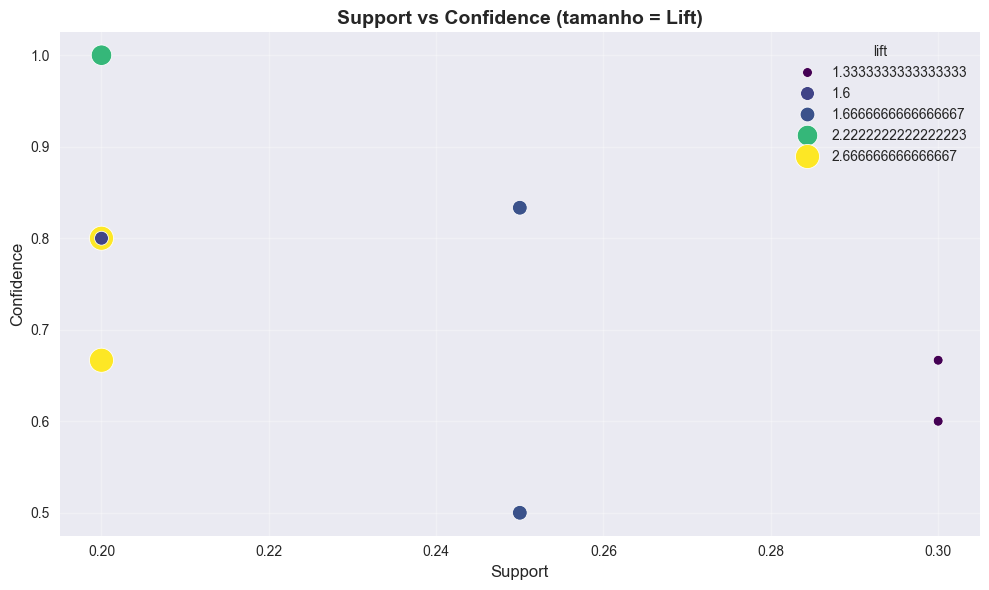

In [7]:
# Gráfico de dispersão: support vs confidence, tamanho por lift
plt.figure(figsize=(10, 6))
scatter = sns.scatterplot(data=rules, x='support', y='confidence', 
                         size='lift', hue='lift', sizes=(50, 300), 
                         palette='viridis', legend=True)
plt.title('Support vs Confidence (tamanho = Lift)', fontsize=14, fontweight='bold')
plt.xlabel('Support', fontsize=12)
plt.ylabel('Confidence', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 8. Visualização: Grafo de Rede

C:\Users\calab\AppData\Local\Temp\ipykernel_11464\1563136849.py:16: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


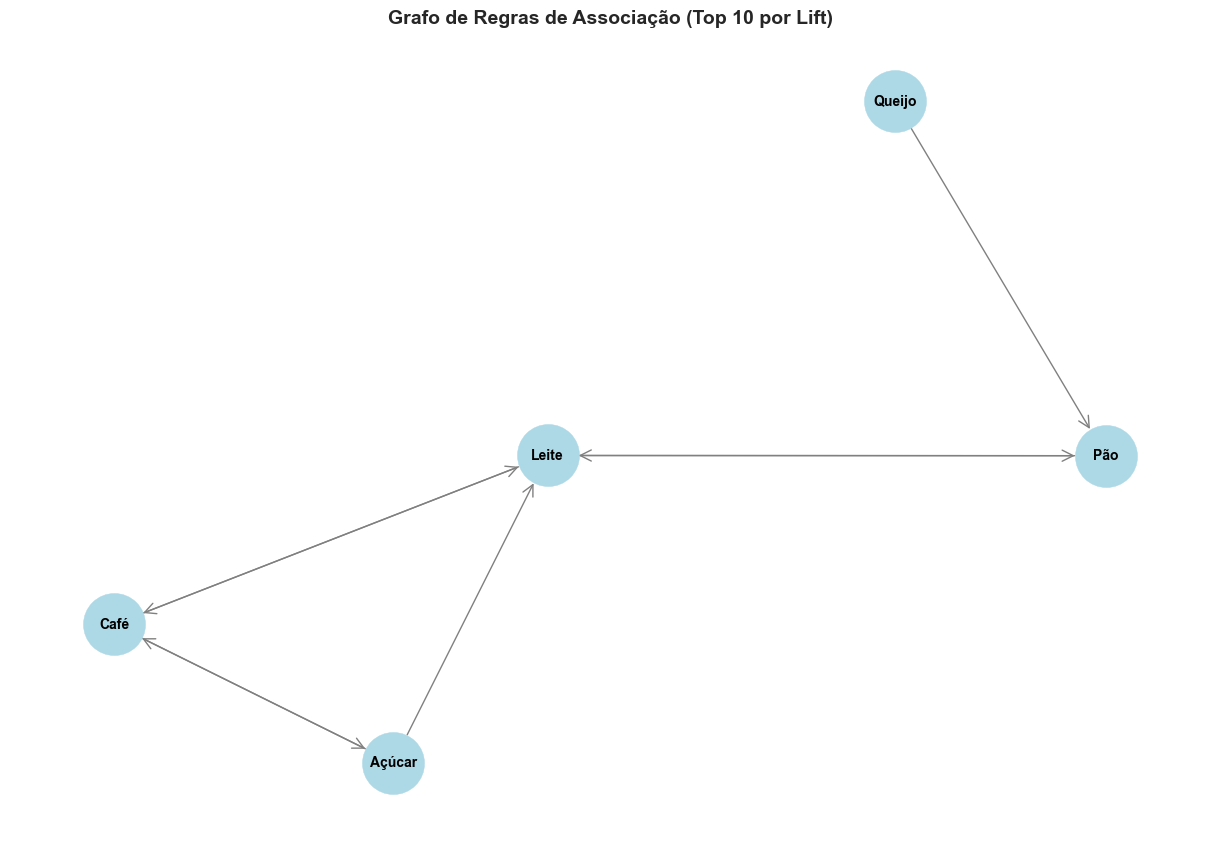

In [8]:
# Grafo de rede das regras (top 10 por lift)
G = nx.DiGraph()
top_rules = rules.nlargest(10, 'lift')

for idx, row in top_rules.iterrows():
    ants = list(row['antecedents'])[0]
    cons = list(row['consequents'])[0]
    G.add_edge(ants, cons, weight=row['lift'])

pos = nx.spring_layout(G, k=1.5, iterations=50)
plt.figure(figsize=(12, 8))
nx.draw(G, pos, with_labels=True, node_color='lightblue', node_size=2000,
        font_size=10, font_weight='bold', arrows=True, edge_color='gray',
        arrowsize=20, arrowstyle='->')
plt.title('Grafo de Regras de Associação (Top 10 por Lift)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 9. Função de Recomendação Personalizada

In [9]:
def recommend(basket, rules_df, max_recs=3):
    """
    Recomenda produtos dado uma cesta atual.
    
    Args:
        basket: lista de itens na cesta
        rules_df: DataFrame com regras de associação
        max_recs: número máximo de recomendações
    
    Returns:
        lista de tuplas (item, confidence, lift)
    """
    basket_set = set(basket)
    recs = []
    
    for idx, rule in rules_df.iterrows():
        ant = set(rule['antecedents'])
        # Se antecedentes estão na cesta
        if ant.issubset(basket_set):
            cons = list(rule['consequents'])[0]
            # Não recomendar itens já presentes
            if cons not in basket_set:
                recs.append({
                    'item': cons,
                    'confidence': rule['confidence'],
                    'lift': rule['lift']
                })
    
    # Ordenar por lift e confidence
    recs.sort(key=lambda x: (x['lift'], x['confidence']), reverse=True)
    return recs[:max_recs]

print('Função de recomendação carregada com sucesso!')

Função de recomendação carregada com sucesso!


## 10. Testes de Recomendação

In [10]:
# Exemplo 1: Cesta com 'Leite' e 'Pão'
cesta1 = ['Leite', 'Pão']
recs1 = recommend(cesta1, rules)
print(f'Cesta: {cesta1}')
print(f'Recomendações:')
if recs1:
    for i, rec in enumerate(recs1):
        print(f"  {i+1}. {rec['item']} (confidence: {rec['confidence']:.2%}, lift: {rec['lift']:.2f})")
else:
    print('  Nenhuma recomendação disponível')

print('\n' + '='*50 + '\n')

# Exemplo 2: Cesta com 'Café'
cesta2 = ['Café']
recs2 = recommend(cesta2, rules)
print(f'Cesta: {cesta2}')
print(f'Recomendações:')
if recs2:
    for i, rec in enumerate(recs2):
        print(f"  {i+1}. {rec['item']} (confidence: {rec['confidence']:.2%}, lift: {rec['lift']:.2f})")
else:
    print('  Nenhuma recomendação disponível')

print('\n' + '='*50 + '\n')

# Exemplo 3: Cesta vazia
cesta3 = []
recs3 = recommend(cesta3, rules)
print(f'Cesta: {cesta3}')
print(f'Recomendações: {recs3}')

Cesta: ['Leite', 'Pão']
Recomendações:
  1. Café (confidence: 50.00%, lift: 1.67)


Cesta: ['Café']
Recomendações:
  1. Açúcar (confidence: 66.67%, lift: 2.67)
  2. Leite (confidence: 83.33%, lift: 1.67)


Cesta: []
Recomendações: []


## 11. Comparação de Performance: Apriori vs FP-Growth

In [11]:
import time

# Timing Apriori
start = time.time()
freq_apriori = apriori(df, min_support=0.2, use_colnames=True)
time_apriori = time.time() - start

# Timing FP-Growth
start = time.time()
freq_fpg = fpgrowth(df, min_support=0.2, use_colnames=True)
time_fpg = time.time() - start

print('Performance Comparison:')
print(f'Apriori:   {time_apriori:.4f}s ({len(freq_apriori)} itemsets)')
print(f'FP-Growth: {time_fpg:.4f}s ({len(freq_fpg)} itemsets)')
print(f'\nSpeedup: {time_apriori/time_fpg:.2f}x')

# Verificar se itemsets são iguais
apriori_sets = set(frozenset(i) for i in freq_apriori['itemsets'])
fpg_sets = set(frozenset(i) for i in freq_fpg['itemsets'])
print(f'Itemsets idênticos: {apriori_sets == fpg_sets}')

Performance Comparison:
Apriori:   0.0050s (11 itemsets)
FP-Growth: 0.0040s (11 itemsets)

Speedup: 1.25x
Itemsets idênticos: True


## 12. Casos de Uso Reais

### E-commerce (Amazon, Mercado Livre)
- **Objetivo**: Aumentar ticket médio (AOV)
- **Estratégia**: "Você também pode gostar" e "Frequentemente comprado junto"
- **KPIs**: CTR, conversão, AOV

### Varejo Físico (Supermercados)
- **Objetivo**: Otimizar layout da loja
- **Estratégia**: Posicionar itens associados longe para aumentar caminhada
- **Trade-off**: Vendas cruzadas vs ticket médio

### Dados Públicos (EMPREL/Recife)
- **Objetivo**: Identificar padrões em serviços municipais
- **Exemplo**: Bairros com alto desemprego também têm baixa educação?
- **Aplicação**: Otimizar alocação de recursos públicos
- **Cuidado**: Privacidade ao publicar resultados com dados sensíveis